In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from matplotlib import patheffects

In [4]:
from PIL import Image
import os, zipfile

In [13]:
rng = np.random.default_rng(42)

W, H = 16, 14
dpi = 180

fig, ax = plt.subplots(figsize=(W, H), dpi=dpi)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")
ax.set_aspect('equal', adjustable='box')

# Star field
n_stars = 450
xs = rng.uniform(0, 16, n_stars)
ys = rng.uniform(0, 9, n_stars)
sizes = rng.choice([0.7, 1.1, 1.6, 2.5, 4.0], size=n_stars, p=[0.48, 0.28, 0.15, 0.07, 0.02])
alphas = rng.uniform(0.25, 0.95, n_stars)
ax.scatter(xs, ys, s=sizes, color=[(1, 1, 1, a) for a in alphas], linewidths=0)

# A few brighter stars
for x, y, s in [(13.9, 6.8, 22), (4.8, 7.5, 10), (10.6, 2.2, 8), (2.4, 1.0, 7)]:
    ax.scatter(x, y, s=s*7, color=(1.0, 0.8, 0.45, 0.07), linewidths=0)
    ax.scatter(x, y, s=s, color=(1, 1, 1, 0.85), linewidths=0)

# Black hole / photon-ring schematic
cx, cy = 3.85, 4.62
r_shadow = 1.02

# Glows
for r, alpha, lw in [(1.62, 0.06, 25), (1.45, 0.08, 18), (1.25, 0.12, 12), (1.05, 0.15, 8)]:
    ax.add_patch(Circle((cx, cy), r, fill=False, lw=lw, color=(1.0, 0.48, 0.07, alpha)))

theta = np.linspace(0, 2*np.pi, 600)
for k, (base_r, lw, alpha) in enumerate([(1.22, 4.5, 0.55), (1.30, 2.5, 0.48), (1.42, 1.3, 0.72)]):
    waviness = 0.018*np.sin(5*theta + k) + 0.012*np.sin(11*theta + 0.7*k)
    asym = 1 + 0.10*np.cos(theta - 0.2)
    rr = base_r*asym + waviness
    xring = cx + rr*np.cos(theta)
    yring = cy + 0.82*rr*np.sin(theta)
    ax.plot(xring, yring, color=(1.0, 0.58, 0.13, alpha), lw=lw, solid_capstyle="round",
            path_effects=[patheffects.Stroke(linewidth=lw+4, foreground=(1.0, 0.35, 0.02, 0.12)),
                          patheffects.Normal()])

# Shadow and ring edges
ax.add_patch(Circle((cx, cy), r_shadow, color="black", zorder=20))
ax.plot(cx + 1.08*np.cos(theta), cy + 0.88*np.sin(theta),
        color=(1.0, 0.66, 0.22, 0.95), lw=3.0, zorder=25,
        path_effects=[patheffects.Stroke(linewidth=8, foreground=(1.0, 0.42, 0.05, 0.20)),
                      patheffects.Normal()])
ax.plot(cx + 1.75*np.cos(theta), cy + 1.43*np.sin(theta),
        color=(1.0, 0.69, 0.28, 0.88), lw=1.25, zorder=15)

# Mathematical damped waveform
x0, x1, N = 5.15, 15.5, 1400
x = np.linspace(x0, x1, N)
t = x - x0
envelope = 1.55 * (1 - np.exp(-1.7*t)) * np.exp(-0.31*t)
phase = 2*np.pi*(1.35*t + 0.055*t**2)
y = cy + envelope*np.sin(phase) + 0.08*np.exp(-0.7*t)*np.sin(7*np.pi*t)

# Wave glow
for lw, alpha in [(20, 0.035), (12, 0.06), (7, 0.10), (4, 0.20)]:
    ax.plot(x, y, color=(1.0, 0.45, 0.06, alpha), lw=lw, solid_capstyle="round", zorder=10)

# Fading core
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
fade = np.linspace(1.0, 0.28, N-1)
colors = np.column_stack([
    np.ones(N-1),
    np.full(N-1, 0.62),
    np.full(N-1, 0.18),
    fade
])
lc = LineCollection(segments, colors=colors, linewidths=2.6, capstyle="round", zorder=30)
ax.add_collection(lc)

# Merger spark
spark_x, spark_y = 5.45, cy
for s, a in [(1000, 0.06), (450, 0.11), (180, 0.22), (55, 0.92)]:
    ax.scatter([spark_x], [spark_y], s=s, color=(1.0, 0.56, 0.09, a), linewidths=0, zorder=35)
ax.plot([4.95, 5.75], [cy, cy], color=(1.0, 0.72, 0.30, 0.8), lw=1.1, zorder=34)

plt.tight_layout(pad=0)

png_path = "C:/Users/palom/Desktop/BHH/procedural_black_hole_ringdown.png"
svg_path = "C:/Users/palom/Desktop/BHH/procedural_black_hole_ringdown.svg"

fig.savefig(png_path, dpi=dpi, facecolor="black", bbox_inches="tight", pad_inches=0)
fig.savefig(svg_path, facecolor="black", bbox_inches="tight", pad_inches=0)
plt.close(fig)

print("Created:")
print(png_path)
print(svg_path)


Created:
C:/Users/palom/Desktop/BHH/procedural_black_hole_ringdown.png
C:/Users/palom/Desktop/BHH/procedural_black_hole_ringdown.svg


In [14]:
src = "C:/Users/palom/Desktop/BHH/procedural_black_hole_ringdown.png"
img = Image.open(src).convert("RGB")

# Center-crop/pad is not needed because it is already 16:9-ish.
# Resize to common press/social sizes.
exports = [
    ("ringdown_press_3840x2160.png", (3840, 2160), "PNG"),
    ("ringdown_press_3840x2160.jpg", (3840, 2160), "JPEG"),
    ("ringdown_web_1920x1080.png", (1920, 1080), "PNG"),
    ("ringdown_web_1920x1080.jpg", (1920, 1080), "JPEG"),
]

paths = []
for filename, size, fmt in exports:
    out = f"C:/Users/palom/Desktop/BHH/{filename}"
    resized = img.resize(size, Image.Resampling.LANCZOS)
    if fmt == "JPEG":
        resized.save(out, quality=95, optimize=True, progressive=True)
    else:
        resized.save(out, optimize=True)
    paths.append(out)

zip_path = "C:/Users/palom/Desktop/BHH/ringdown_press_image_exports.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in paths:
        z.write(p, arcname=os.path.basename(p))

print("Created:")
for p in paths:
    print(p, Image.open(p).size, f"{os.path.getsize(p)/1024/1024:.2f} MB")
print(zip_path, f"{os.path.getsize(zip_path)/1024/1024:.2f} MB")


Created:
C:/Users/palom/Desktop/BHH/ringdown_press_3840x2160.png (3840, 2160) 0.78 MB
C:/Users/palom/Desktop/BHH/ringdown_press_3840x2160.jpg (3840, 2160) 0.32 MB
C:/Users/palom/Desktop/BHH/ringdown_web_1920x1080.png (1920, 1080) 0.27 MB
C:/Users/palom/Desktop/BHH/ringdown_web_1920x1080.jpg (1920, 1080) 0.13 MB
C:/Users/palom/Desktop/BHH/ringdown_press_image_exports.zip 1.44 MB


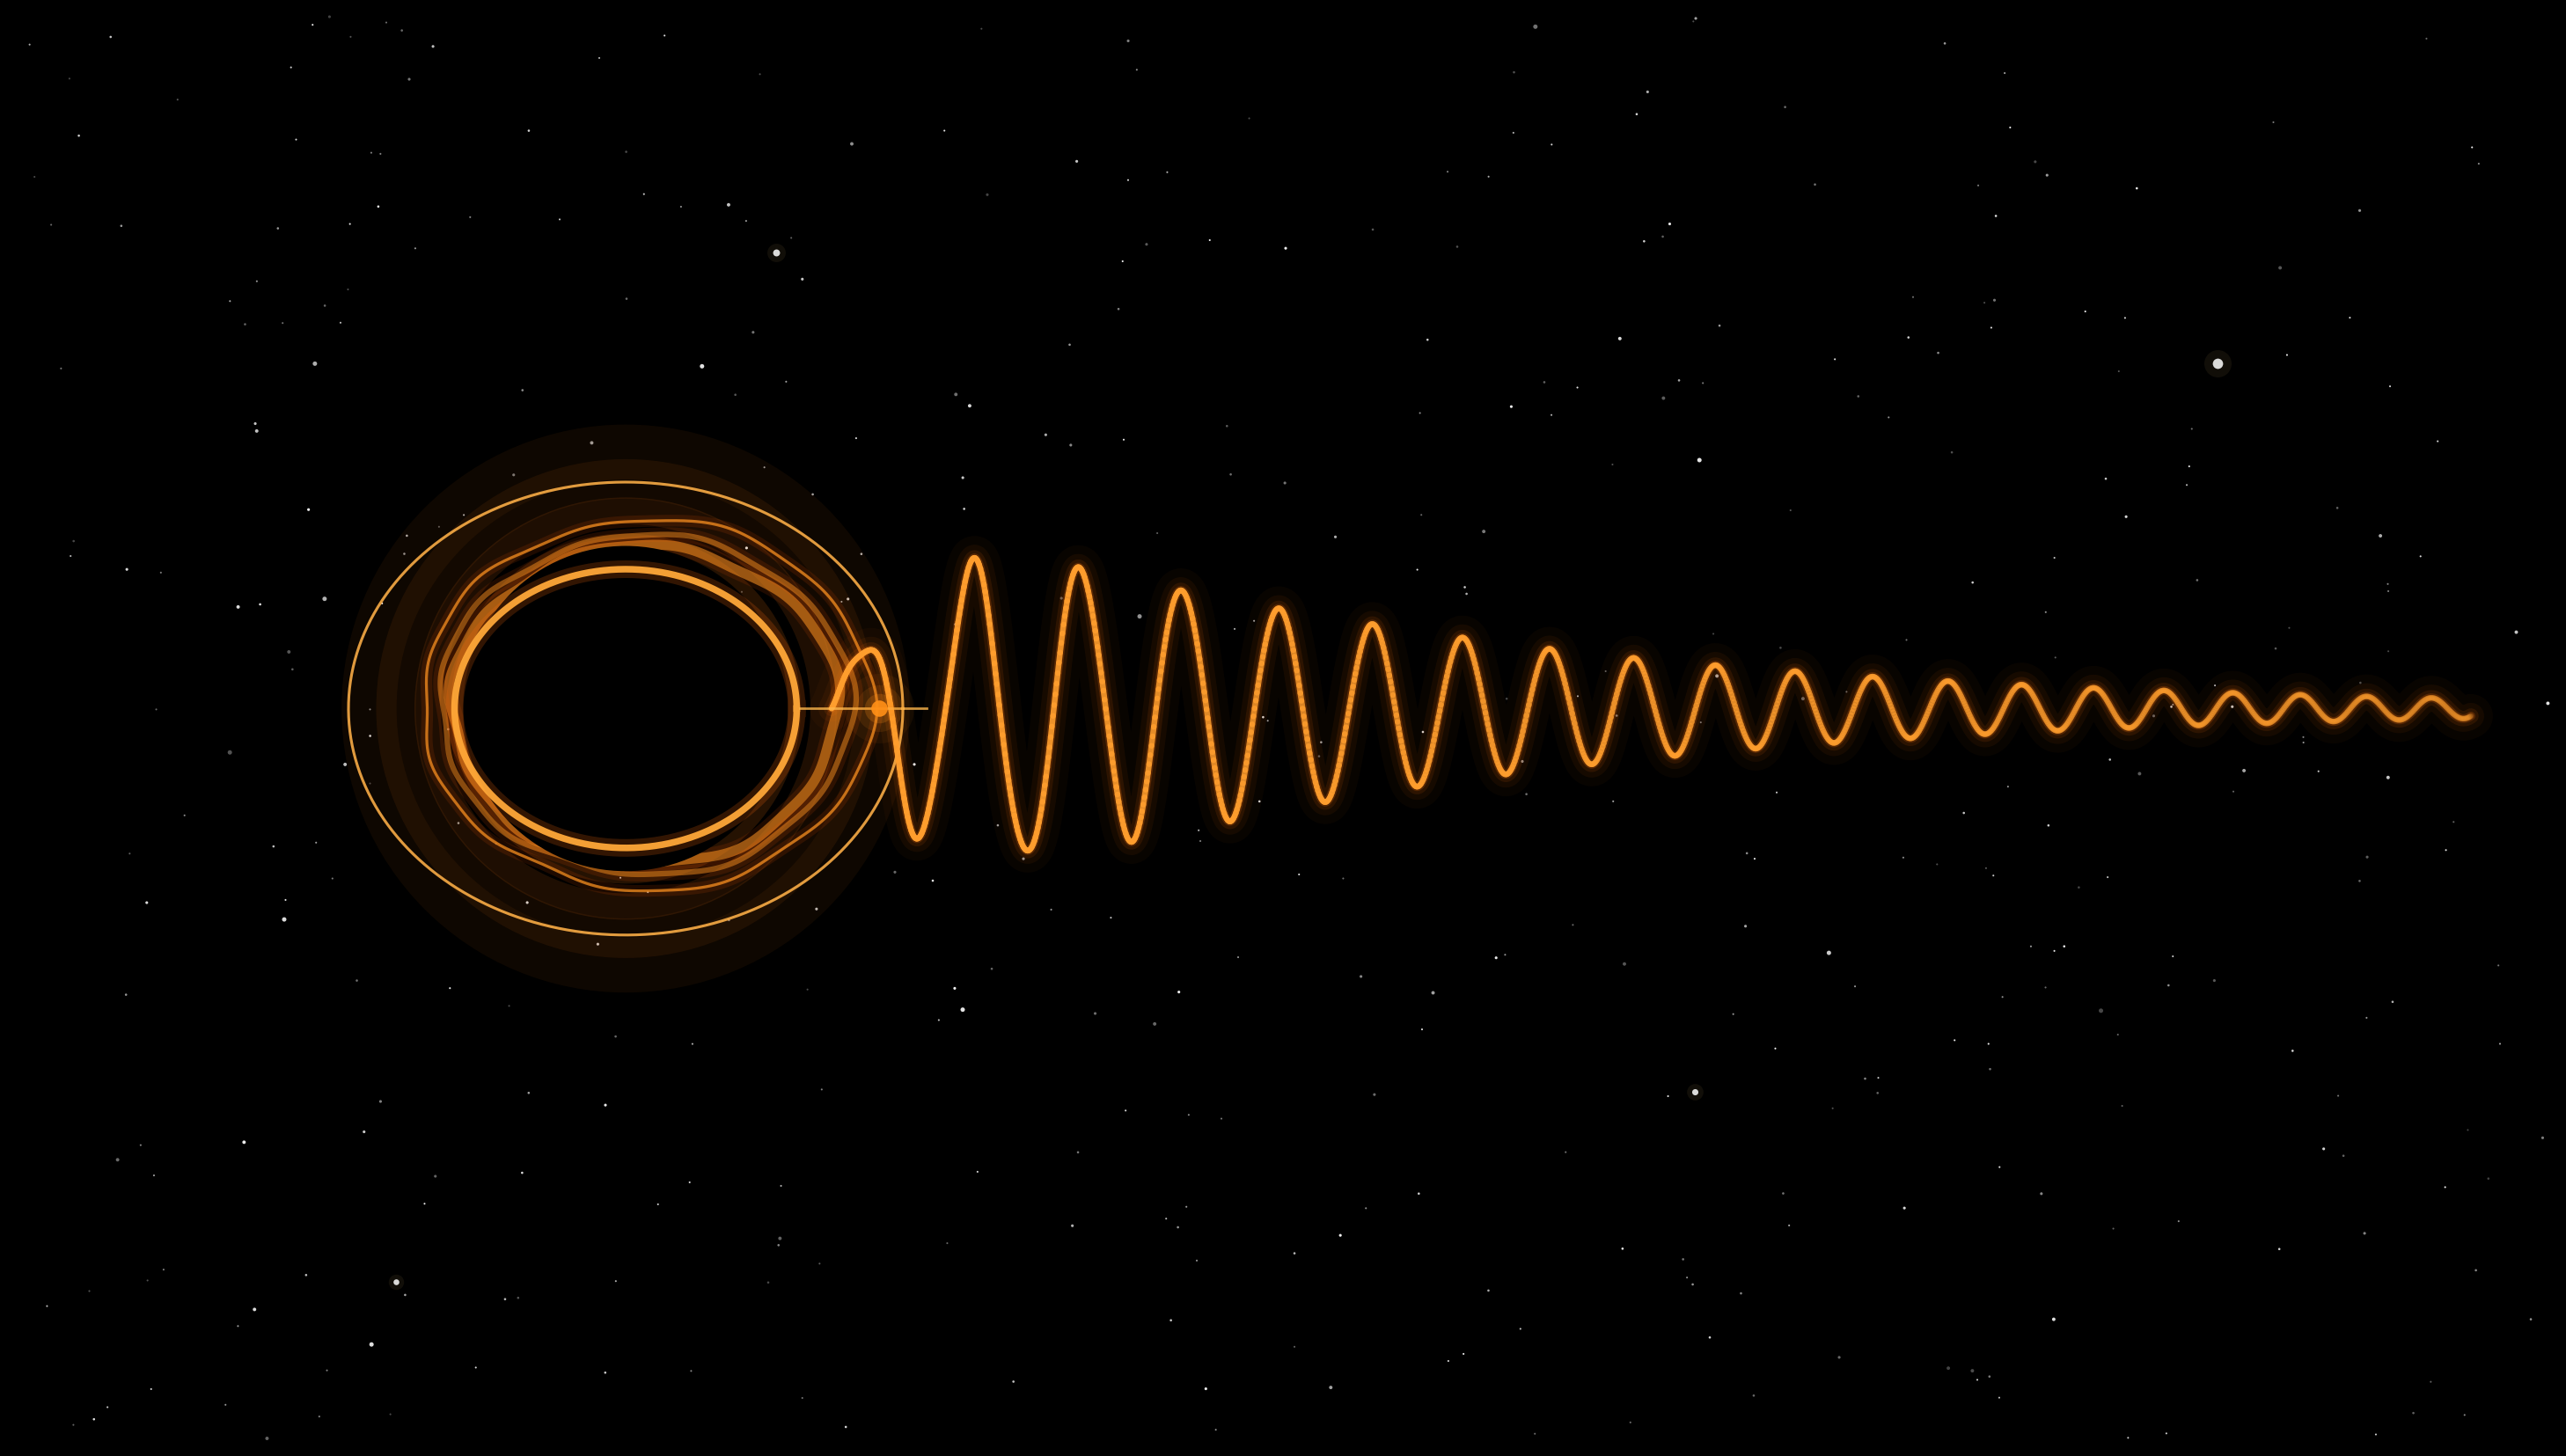

In [15]:
fig